In [2]:
import pandas as pd
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [3]:
base_dir = r'..\..\BBBD-unzipped'

########################################## Heart data ######################################
exp_derivatives_paths = [
    r'experiment2\derivatives',
    r'experiment3\derivatives',
    r'experiment4\derivatives',
    r'experiment5\derivatives',
]

bids_directories_eeg = [os.path.join(base_dir, os.path.normpath(path)) for path in exp_derivatives_paths] # Constructing full paths

bids_directories_heart = [os.path.join(base_dir, os.path.normpath(path)) for path in exp_derivatives_paths]

experiments_heart = [f'ex{i+2}' for i in range(len(bids_directories_heart))]

########################################## Eye data ######################################
bids_directories_eye = [os.path.join(base_dir, os.path.normpath(r'experiment1\derivatives'))] + bids_directories_heart

experiments_eye = [f'ex{i+1}' for i in range(len(bids_directories_eye))]

### Figure 5A

In [ ]:
import os
os.environ.pop('MPLBACKEND', None)  # Fix: clears the Jupyter inline backend env var before matplotlib loads
import matplotlib
matplotlib.use('Agg')  # Use 'TkAgg' if you want an interactive popup window
import matplotlib.pyplot as plt
import numpy as np
import mne
import glob

def compute_psd_by_region(bids_dir, regions):
    psd_results = {
        'ses-01': {region: [] for region in regions.keys()},  # Attend
        'ses-02': {region: [] for region in regions.keys()}   # Distract
    }
    freqs = None  

    for session in psd_results.keys():
        # Construct the path to find BDF files
        session_path = os.path.join(bids_dir, f'sub-*', session, 'eeg', '*eeg.bdf')
        bdf_files = glob.glob(session_path)

        for bdf_file in bdf_files:
            raw = mne.io.read_raw_bdf(bdf_file, preload=True)
            for region, channels in regions.items():
                picks = mne.pick_channels(raw.info['ch_names'], include=channels)
                if len(picks) == 0:  
                    continue
                psd = raw.compute_psd(method='welch', fmin=0.1, fmax=64, n_fft=512, picks=picks, average='mean')
                psd_data, freqs = psd.get_data(return_freqs=True)
                psd_results[session][region].append(psd_data)
        
    averaged_psd = {}
    sem_psd = {}  # Added: store SEM alongside averages
    for session, regions_psd in psd_results.items():
        averaged_psd[session] = {}
        sem_psd[session] = {}  # Added
        for region, psds in regions_psd.items():
            if psds:
                max_length = max(psd.shape[1] for psd in psds)
                padded_psds = []
                for psd in psds:
                    if psd.shape[1] < max_length:
                        pad_width = max_length - psd.shape[1]
                        psd = np.pad(psd, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
                    padded_psds.append(psd)
                stacked = np.array(padded_psds)  # (n_subjects, n_channels, n_freqs)
                averaged_psd[session][region] = np.mean(stacked, axis=0)
                # Added: SEM across subjects, averaged across channels to match the mean shape
                subject_means = stacked.mean(axis=1)  # (n_subjects, n_freqs)
                sem_psd[session][region] = subject_means.std(axis=0, ddof=1) / np.sqrt(subject_means.shape[0])

    return freqs, averaged_psd, sem_psd  # Added: return sem_psd

experiment_labels = ['Exp 2', 'Exp 3', 'Exp 4', 'Exp 5']
exp_dict = {
    'ex2': {'ses-01': {}, 'ses-02': {}},
    'ex3': {'ses-01': {}, 'ses-02': {}},
    'ex4': {'ses-01': {}, 'ses-02': {}},
    'ex5': {'ses-01': {}, 'ses-02': {}},
}
sem_dict = {  # Added: mirrors exp_dict structure for SEM
    'ex2': {'ses-01': {}, 'ses-02': {}},
    'ex3': {'ses-01': {}, 'ses-02': {}},
    'ex4': {'ses-01': {}, 'ses-02': {}},
    'ex5': {'ses-01': {}, 'ses-02': {}},
}

raw = mne.io.read_raw_bdf(os.path.join(bids_directories_eeg[0], r'sub-01\ses-01\eeg\sub-01_ses-01_task-stim01_desc-eeg.bdf')) # Loading a sample EEG signal from Exp 2 to extract channel labels. Exp2 Directory: bids_directories_eeg[0] 
chanlocs_labels = raw.ch_names

regions = {
    'Frontal': [ch for ch in chanlocs_labels if ch.startswith('F')],
    'Central': [ch for ch in chanlocs_labels if ch.startswith('C')],
    'Temporal': [ch for ch in chanlocs_labels if ch.startswith('T')],
    'Parietal': [ch for ch in chanlocs_labels if ch.startswith('P')],
    'Occipital': [ch for ch in chanlocs_labels if ch.startswith('O')]
}

##############################################################################################################

for exp_index, bids_directory in enumerate(bids_directories_eeg):
    freqs, averaged_psd, sem_psd = compute_psd_by_region(bids_directory, regions)  # Added: unpack sem_psd

    exp_label = f'ex{exp_index + 2}'  
    for i, region in enumerate(regions.keys()):
        if region in averaged_psd['ses-01']:
            if region not in exp_dict[exp_label]['ses-01']:
                exp_dict[exp_label]['ses-01'][region] = []
                sem_dict[exp_label]['ses-01'][region] = []  # Added
            exp_dict[exp_label]['ses-01'][region].append(np.mean(averaged_psd['ses-01'][region], axis=0))
            sem_dict[exp_label]['ses-01'][region].append(sem_psd['ses-01'][region])  # Added

        if region in averaged_psd['ses-02']:
            if region not in exp_dict[exp_label]['ses-02']:
                exp_dict[exp_label]['ses-02'][region] = []
                sem_dict[exp_label]['ses-02'][region] = []  # Added
            exp_dict[exp_label]['ses-02'][region].append(np.mean(averaged_psd['ses-02'][region], axis=0))
            sem_dict[exp_label]['ses-02'][region].append(sem_psd['ses-02'][region])  # Added
            
##############################################################################################################

avg_dict = {}
avg_sem_dict = {}  # Added
for exp, sessions in exp_dict.items():
    avg_dict[exp] = {}  # Initialize for each experiment
    avg_sem_dict[exp] = {}  # Added
    region_sums = {}
    region_counts = {}
    region_sem_sums = {}  # Added
    
    for ses, regions_ch in sessions.items():
        for region, values in regions_ch.items():
            if region not in region_sums:
                region_sums[region] = 0
                region_counts[region] = 0
                region_sem_sums[region] = 0  # Added
            region_sums[region] += sum(values)
            region_counts[region] += len(values)
            region_sem_sums[region] += sum(sem_dict[exp][ses].get(region, [0]))  # Added
    
    for region in region_sums:
        avg_dict[exp][region] = region_sums[region] / region_counts[region]
        avg_sem_dict[exp][region] = region_sem_sums[region] / region_counts[region]  # Added

Extracting BDF parameters from ..\..\BBBD-unzipped\experiment2\derivatives\sub-01\ses-01\eeg\sub-01_ses-01_task-stim01_desc-eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Extracting BDF parameters from ..\..\BBBD-unzipped\experiment2\derivatives\sub-01\ses-01\eeg\sub-01_ses-01_task-stim01_desc-eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 23679  =      0.000 ...   184.992 secs...
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Extracting BDF parameters from ..\..\BBBD-unzipped\experiment2\derivatives\sub-01\ses-01\eeg\sub-01_ses-01_task-stim02_desc-eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 18303  =      0.000 ...   142.992 secs...
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Effective window size : 4.000 (s)
Effective window

C:\Users\Neuro\AppData\Local\Temp\ipykernel_7000\3349475259.py:161: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


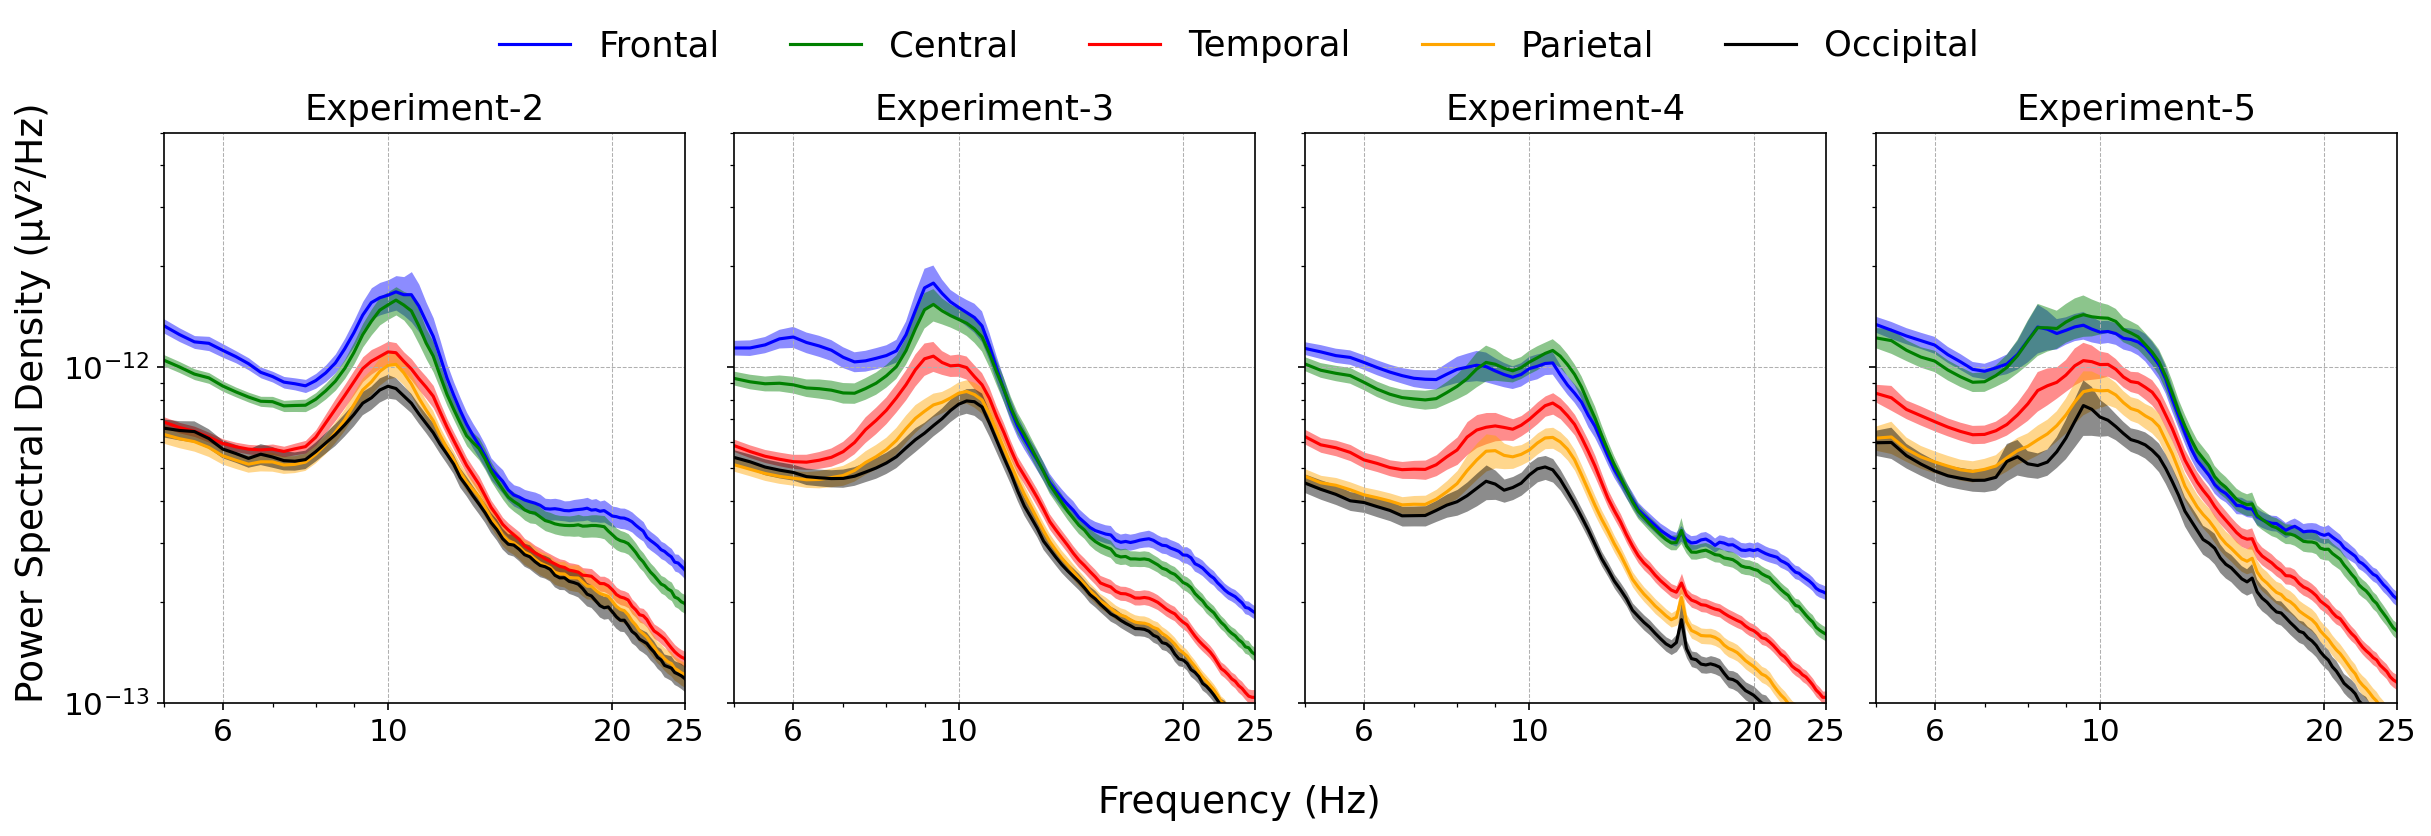

In [12]:
colors = ['blue', 'green', 'red', 'orange', 'black']
exp_names = ['Experiment-2', 'Experiment-3', 'Experiment-4', 'Experiment-5']
eeg_band_ticks = np.array([6, 10, 20, 25]) 

# Plot setup
fig, axes = plt.subplots(1, 4, figsize=(16, 5.7), sharex=True, sharey=True)
# Iterate over each experiment
for i, exp_name in enumerate(avg_dict):
    ax = axes[i]
    ax.set_title(exp_names[i])
    for region_num, (region, data) in enumerate(avg_dict[exp_name].items()):
        color = colors[region_num % len(colors)]  
        psd_avg = data 
        psd_sem = avg_sem_dict[exp_name][region]  # Added
        ax.plot(freqs[:234], psd_avg[:234], label=region, color=color, linewidth=1.5)
        ax.fill_between(freqs[:234], psd_avg[:234] - psd_sem[:234], psd_avg[:234] + psd_sem[:234],  # Added
                        color=color, alpha=0.45, linewidth=0)  # Added
    
    ax.set_xscale('log') 
    ax.set_yscale('log')  
    # ax.set_xlim(0.5, 64)  
    # ax.set_ylim(1e-14, 1e-10)  
    ax.set_xlim(5, 25)   # focus on the meaningful range, cuts noisy low end and stops at 30 Hz
    ax.set_ylim(1e-13, 0.5e-11)  # expand y range so the SEM shading becomes visible
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_xticks(eeg_band_ticks)
    # ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())  # Ensure ticks are shown as numbers
    ax.set_xticklabels([f"{int(t) if t.is_integer() else f'{t:.1f}'}" for t in eeg_band_ticks], fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    ax.set_title(exp_names[i], fontsize=17)


fig.text(0.5, 0.02, 'Frequency (Hz)', ha='center', fontsize=18)
fig.text(-0.01, 0.5, 'Power Spectral Density (µV²/Hz)', va='center', rotation='vertical', fontsize=18)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.86), ncol=len(regions), frameon=False, fontsize=17)

plt.tight_layout(rect=[0, 0.07, 1, 0.89])  

import io
from IPython.display import Image, display
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image(buf.read()))

### Figure 5B - MATLAB File [figure-5b-topoplot.m]

### Figure 6

Heart Rate (mean of medians) Violin Plot
Heart Rate Variability (mean of RMSSDs) Violin Plot


C:\Users\Neuro\AppData\Local\Temp\ipykernel_27236\2378556349.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Neuro\AppData\Local\Temp\ipykernel_27236\2378556349.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


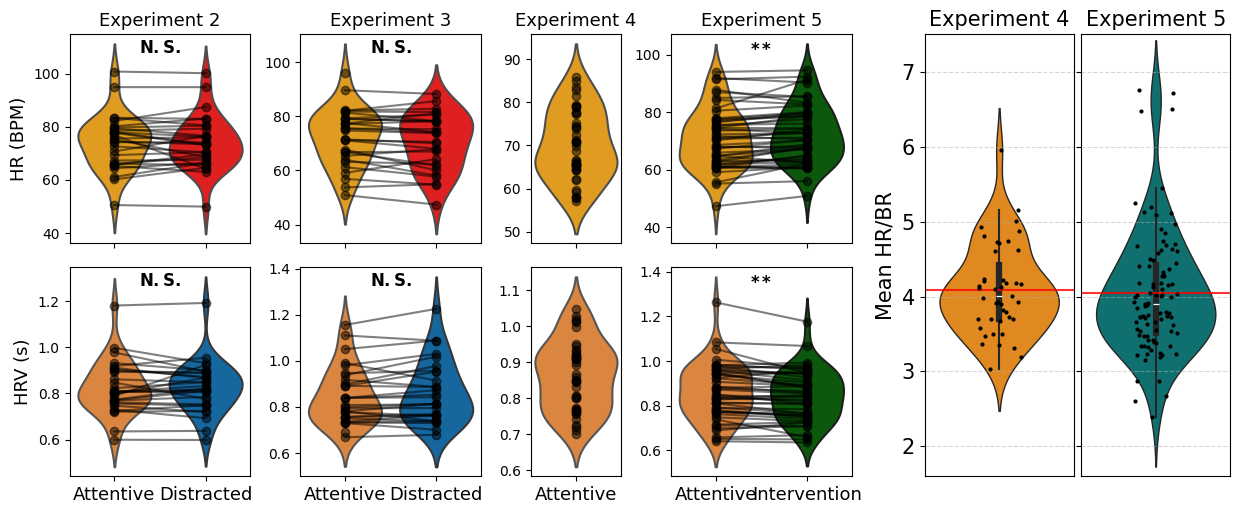

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

def violin_df(exp_dict):
    ses_01 = exp_dict['ex4']['ses-01']
    ses_02 = exp_dict['ex4']['ses-02']
    combined_session = {
        sub: np.mean([ses_01.get(sub, np.nan), ses_02.get(sub, np.nan)])
        for sub in set(ses_01.keys()).union(ses_02.keys())
    }
    exp_dict['ex4']['ses-01'] = combined_session
    del exp_dict['ex4']['ses-02']
    rows = []
    for ex, sessions in exp_dict.items():
        for session, subjects in sessions.items():
            for sub, value in subjects.items():
                rows.append({'Experiment': ex, 'Session': session, 'Subject': sub, 'Value': value})

    return pd.DataFrame(rows)

def cohen_d_paired(x,y):
    diff = x-y
    return np.mean(diff)/np.std(diff)
    
def ttest_df(df_measure):
    paired_tests = []
    for experiment, group in df_measure.groupby('Experiment'):
        if experiment == 'ex4':
            continue
        ses1 = group[group['Session'] == 'ses-01'].set_index('Subject')['Value']
        ses2 = group[group['Session'] == 'ses-02'].set_index('Subject')['Value']
        
        common_subjects = ses1.index.intersection(ses2.index)
        ses1 = ses1.loc[common_subjects]
        ses2 = ses2.loc[common_subjects]

        t_stat, p_value = ttest_rel(ses2, ses1)
        df = len(ses2) - 1
        paired_tests.append({
            'Experiment': experiment,
            't_stat': t_stat,
            'p_value': p_value,
            'df': df,
            'd`': cohen_d_paired(ses2,ses1)
            })
    return pd.DataFrame(paired_tests)
            
def hr_br_calc(bids_dir, file_type):
    hr_br_results = {
        'ses-01': {},  # Attend
        'ses-02': {}   # Distract
    }
    subdirs = os.listdir(bids_dir)

    for session in hr_br_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'beh', file_type)
            files = glob.glob(session_path)  

            total_weighted_mean = 0
            total_samples = 0

            for file in files:
                try:
                    # Read the HR data
                    data = pd.read_csv(file, sep='\t', compression='gzip', header=None)
                    data_column = data.iloc[:, 0] 
                    mean = np.mean(data_column)  
                    n_samples = len(data_column)

                    if not np.isnan(mean) and n_samples > 1:
                        total_weighted_mean += n_samples * mean
                        total_samples += n_samples 

                except Exception as e:
                    print(f"Error processing file {file}: {e}")
                    continue

            # Calculate weighted mean if data is available
            if total_samples > 0:
                weighted_mean = total_weighted_mean / total_samples
                hr_br_results[session][sub] = weighted_mean
    
    return hr_br_results

# Using only exp 4 and 5 data as they have respiration
hrbr_paths = [r'experiment4\derivatives', r'experiment5\derivatives']
bids_directories_hrbr = [os.path.join(base_dir, os.path.normpath(path)) for path in hrbr_paths]

experiment_labels = ['Exp 4', 'Exp 5']
exp_dict_hr_means = {
    'ex4': {},
    'ex5': {},
}
exp_dict_br_means = {
    'ex4': {},
    'ex5': {},
}

for exp_index, bids_directory in enumerate(bids_directories_hrbr): 
    exp_label = f'ex{exp_index + 4}'  # Creates labels 'ex1', 'ex2', 'ex3'
    print('Experiment: ', exp_label)
    hr_means = hr_br_calc(bids_directory, '*heartrate.tsv.gz')
    exp_dict_hr_means[exp_label] = hr_means
    br_means = hr_br_calc(bids_directory, '*breathrate.tsv.gz')
    exp_dict_br_means[exp_label] = br_means

exp_dict_ratio = {}

for exp in exp_dict_hr_means:
    if exp in exp_dict_br_means: 
        exp_dict_ratio[exp] = {}  
        
        for ses in exp_dict_hr_means[exp]:
            if ses in exp_dict_br_means[exp]: 
                exp_dict_ratio[exp][ses] = {} 
                
                for sub in exp_dict_hr_means[exp][ses]:
                    if sub in exp_dict_br_means[exp][ses]:  
                        hr_value = exp_dict_hr_means[exp][ses][sub]
                        br_value = exp_dict_br_means[exp][ses][sub]
                        exp_dict_ratio[exp][ses][sub] = hr_value / br_value

df_hr_br = violin_df(exp_dict_ratio)
df_hr_br["Experiment"] = df_hr_br["Experiment"].replace({"ex4": "Experiment 4", "ex5": "Experiment 5"})

def hr_per_subject(bids_dir):
    hr_results = {
        'ses-01': {},  
        'ses-02': {}  
    }

    subdirs = os.listdir(bids_dir)

    for session in hr_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'beh', '*heartrate.tsv.gz')
            hr_files = glob.glob(session_path)  

            subj_hr = []
            for hr_file in hr_files:
                hr_data = pd.read_csv(hr_file, sep='\t', compression='gzip', header=None)
                hr_column = hr_data.iloc[:, 0] 
                median_hr = np.median(hr_column)

                if not np.isnan(median_hr) and median_hr != 0:
                    subj_hr.append(median_hr)

            if subj_hr:
                hr_results[session][sub] = np.mean(subj_hr)

    return hr_results

def hrv_per_subject(bids_dir):
    hrv_results = {
        'ses-01': {},  # Attend
        'ses-02': {}   # Distract
    }

    subdirs = os.listdir(bids_dir)

    for session in hrv_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'beh', '*rpeak_timestamps.tsv.gz')
            hr_files = glob.glob(session_path)  
            subj_hrv = []

            for hr_file in hr_files:
                try:
                    hr_data = pd.read_csv(hr_file, sep='\t', compression='gzip')
                    hr_column = hr_data.iloc[:, 0] 
                    rmssd = np.sqrt(np.mean(np.diff(hr_column)**2))  # RMSSD
                    subj_hrv.append(rmssd)

                except Exception as e:
                    print(f"Error processing file {hr_file}: {e}")
                    continue
                
            if len(subj_hrv) > 0:
                hrv_results[session][sub] = np.mean(subj_hrv)
    return hrv_results

def violin_plot_heart(df, axes, attentive_color, distract_color, intervention_color, plot_label, ttest_results=None):
    experiments = df['Experiment'].unique()

    if axes is None:
        fig, axes = plt.subplots(1, len(experiments), gridspec_kw={'width_ratios': [2, 2, 1, 2]}, figsize=(10, 2.4), sharey=True)
    else:
        fig = axes[0].figure

    for i, ex in enumerate(experiments):
        ax = axes[i] if len(experiments) > 1 else axes
        ex_data = df[df['Experiment'] == ex]

        if i == 2:
            sessions = ['ses-01']
            exp_sessions = ['Attentive']
        elif i == 3:
            sessions = ['ses-01', 'ses-02']
            exp_sessions = ['Attentive', 'Intervention']
        else:
            sessions = ['ses-01', 'ses-02']
            exp_sessions = ['Attentive', 'Distracted']

        positions = range(len(sessions))

        for j, session in enumerate(sessions):
            session_data = ex_data[ex_data['Session'] == session]
            if session_data.empty:
                print(f"No data for {ex} {session}")
                continue

            color = (
                intervention_color if i == 3 and session != 'ses-01'
                else attentive_color if session == 'ses-01'
                else distract_color
            )

            sns.violinplot(x=[session] * len(session_data), y=session_data['Value'], ax=ax,
                           inner=None, color=color, linewidth=1.5)

        # Subject lines
        subjects = ex_data['Subject'].unique()
        for sub in subjects:
            sub_data = ex_data[ex_data['Subject'] == sub]
            x = [sessions.index(s) for s in sub_data['Session']]
            y = sub_data['Value']
            ax.plot(x, y, marker='o', linestyle='-', color='black', alpha=0.5)

        # Y-axis, X-axis settings
        ax.set_ylabel('')
        if 'HR (BPM)' in plot_label:
            ax.set_title(f"Experiment {i+2}", fontsize=13)
        ax.set_xticks(positions)
        ax.set_xticklabels(exp_sessions if 'HRV' in plot_label else [], fontsize=13)

        if i == 0:
            ax.set_ylabel(plot_label, fontsize=13)

        # ✨ Add significance annotation
        if ttest_results is not None and len(sessions) == 2:
            p_val_row = ttest_results[ttest_results['Experiment'] == ex]
            if not p_val_row.empty:
                p_val = p_val_row.iloc[0]['p_value']
                if p_val < 0.01:
                        sig_label = r'$\mathbf{**}$'
                elif p_val < 0.05:
                    sig_label = r'$\mathbf{*}$'
                else:
                    sig_label = r'$\mathbf{N.S.}$'
                    
                ax.text(0.5, 0.98, sig_label,
                    ha='center', va='top',
                    transform=ax.transAxes,
                    fontsize=12)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    return fig, ax

def process_and_visualise(bids_directories, experiments, data_function, violin_plot_function, plot_label, colors, stat_label, axes):
    data_dict = {exp: {} for exp in experiments}
    
    for exp_index, bids_directory in enumerate(bids_directories): 
        exp_label = experiments[exp_index]
        data = data_function(bids_directory)
        data_dict[exp_label] = data

    df_data = violin_df(data_dict)
    ttest_results = ttest_df(df_data)
    print(f'{stat_label} Violin Plot')
    fig, ax = violin_plot_function(df_data, axes, **colors, plot_label=plot_label, ttest_results=ttest_results)
    return df_data, fig, ax

# Create the main figure with appropriate size and explicit left margin
fig = plt.figure(figsize=(13, 5.8))

# Create two subfigures with a 3:1 width ratio
subfigs = fig.subfigures(1, 2, width_ratios=[3, 1], wspace=0.1)

# Create the left subfigure with 2 rows for HR and HRV
left_subfig = subfigs[0]
left_axs = left_subfig.subplots(2, 4, gridspec_kw={'width_ratios': [2, 2, 1, 2]})
# Add more space on the left margin
left_subfig.subplots_adjust(wspace=0.05, left=0.1)  # Added left margin
left_axs = left_axs.reshape(2, 4)

# Heart Rate → top row
df_hr, _, _ = process_and_visualise(
    bids_directories_heart, experiments_heart, hr_per_subject,
    violin_plot_heart, "HR (BPM)",
    {"attentive_color": "orange", "distract_color": "red", "intervention_color": "darkgreen"},
    "Heart Rate (mean of medians)",
    axes=left_axs[0]
)

# Heart Rate Variability → bottom row
df_hrv, _, _ = process_and_visualise(
    bids_directories_heart, experiments_heart, hrv_per_subject,
    violin_plot_heart, "HRV (s)",
    {"attentive_color": "#F58426", "distract_color": "#006BB6", "intervention_color": "darkgreen"},
    "Heart Rate Variability (mean of RMSSDs)",
    axes=left_axs[1]
)

# Create the right subfigure for HR/BR plot with 2 columns
right_subfig = subfigs[1]
right_axs = right_subfig.subplots(1, 2, sharey=True)
# Also add left margin here to ensure y-labels are visible
right_subfig.subplots_adjust(wspace=0.05, left=0.001)  # Added left margin

experiments = ['Experiment 4', 'Experiment 5']
palette = {
    'Experiment 4': '#FF8C00',
    'Experiment 5': '#008080'
}

for i, exp in enumerate(experiments):
    ax = right_axs[i]
    data = df_hr_br[df_hr_br['Experiment'] == exp]

    sns.violinplot(
        data=data,
        x='Experiment',
        y='Value',
        palette=palette,
        linewidth=1,
        width=0.8,
        dodge=False,
        ax=ax,
        orient="v"
    )

    sns.stripplot(
        data=data,
        x='Experiment',
        y='Value',
        color='black',
        alpha=1,
        size=3,
        jitter=0.15,
        ax=ax
    )

    ax.axhline(data['Value'].mean(), color='red', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_title(exp, fontsize=15)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_facecolor('none')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='y', labelsize=15)

right_axs[0].set_ylabel('Mean HR/BR', fontsize=15)
right_axs[0].set_ylim(1.6, 7.5)

# # Add letters for main subfigures
# def add_subfigure_label(subfig, label, x, y):
#     subfig.text(x, y, label, fontsize=16, fontweight='bold', va='top', ha='right')

# # Move labels inside the subfigures to ensure they're included
# add_subfigure_label(left_subfig, 'A', x=0.2, y=0.95)  # Left top (HR)
# add_subfigure_label(right_subfig, 'C', x=0.5, y=0.97)  # Right (HR/BR)
# left_subfig.text(0.2, 0.48, 'B', fontsize=16, fontweight='bold', va='top', ha='right')

# Don't use tight_layout if you've manually set margins
# Instead, make sure there's room for saving the figure
# plt.savefig('violin_plots_mixedlayout.png', bbox_inches='tight', dpi=800)
plt.show()

### Figure 7

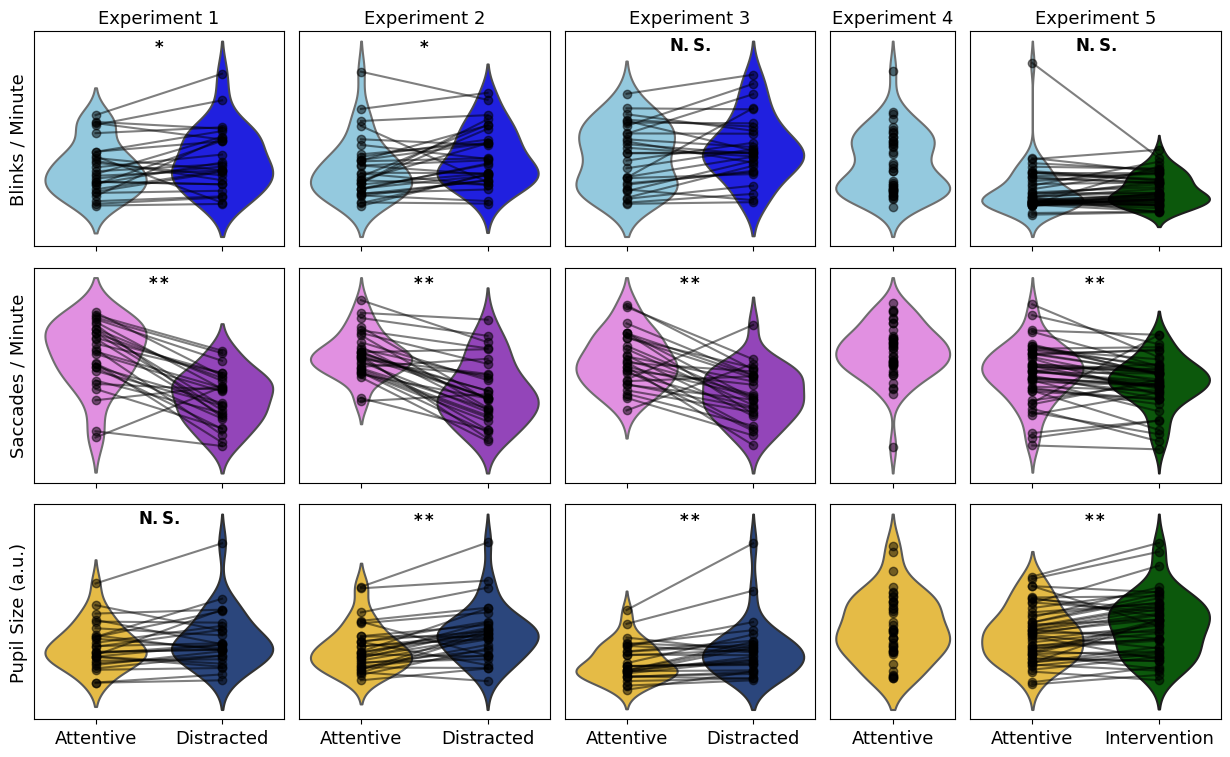

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def pupil_iqr_per_subject(bids_dir):
    iqr_results = {
        'ses-01': {},
        'ses-02': {}
    }
    subdirs = os.listdir(bids_dir)
    for session in iqr_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'eyetrack', '*pupil_eyetrack.tsv.gz')
            hr_files = glob.glob(session_path)
            subj_iqr = []
            for hr_file in hr_files:
                hr_data = pd.read_csv(hr_file, sep='\t', compression='gzip', header=None)
                hr_column = hr_data.iloc[:, 0]
                q75, q25 = np.percentile(hr_column, [75, 25])
                iqr = q75 - q25
                if not np.isnan(iqr) and iqr != 0:
                    subj_iqr.append(iqr)
            if subj_iqr:
                iqr_results[session][sub] = np.mean(subj_iqr)
    return iqr_results


def saccaderate_per_subject(bids_dir):
    sr_results = {
        'ses-01': {},
        'ses-02': {}
    }
    subdirs = os.listdir(bids_dir)
    for session in sr_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'eyetrack', '*saccaderate.tsv.gz')
            cont_files = glob.glob(session_path)
            disc_path = os.path.join(bids_dir, sub, session, 'eyetrack', '*saccades.tsv.gz')
            disc_files = glob.glob(disc_path)
            subj_sr = []
            for cont_file, disc_file in zip(cont_files, disc_files):
                cont_data = pd.read_csv(cont_file, sep='\t', compression='gzip', header=None)
                disc_data = pd.read_csv(disc_file, sep='\t', compression='gzip')
                duration = (len(cont_data) / 128) / 60
                saccaderate = len(disc_data) / duration
                if not np.isnan(saccaderate) and saccaderate != 0:
                    subj_sr.append(saccaderate)
            if subj_sr:
                sr_results[session][sub] = np.mean(subj_sr)
    return sr_results


def blinkrate_per_subject(bids_dir):
    blink_results = {
        'ses-01': {},
        'ses-02': {}
    }
    subdirs = os.listdir(bids_dir)
    for session in blink_results.keys():
        for sub in subdirs:
            session_path = os.path.join(bids_dir, sub, session, 'eyetrack', '*blinkrate.tsv.gz')
            cont_files = glob.glob(session_path)
            disc_path = os.path.join(bids_dir, sub, session, 'eyetrack', '*blinks.tsv.gz')
            disc_files = glob.glob(disc_path)
            subj_blinkrate = []
            for cont_file, disc_file in zip(cont_files, disc_files):
                cont_data = pd.read_csv(cont_file, sep='\t', compression='gzip', header=None)
                disc_data = pd.read_csv(disc_file, sep='\t', compression='gzip')
                duration = (len(cont_data) / 128) / 60
                blinkrate = len(disc_data) / duration
                if not np.isnan(blinkrate) and blinkrate != 0:
                    subj_blinkrate.append(blinkrate)
            if subj_blinkrate:
                blink_results[session][sub] = np.mean(subj_blinkrate)
    return blink_results


def violin_plot_eye(df, attentive_color, distract_color, intervention_color, plot_label):
    experiments = df['Experiment'].unique()
    fig, axes = plt.subplots(1, len(experiments), gridspec_kw={'width_ratios': [2, 2, 2, 1, 2]}, figsize=(16.5, 3), sharey=False)
    for i, ex in enumerate(experiments):
        ax = axes[i] if len(experiments) > 1 else axes
        ex_data = df[df['Experiment'] == ex]
        sessions = ['ses-01', 'ses-02']
        exp_sessions = ['Attentive', 'Distracted']
        if i == 3:
            sessions = ['ses-01']
            exp_sessions = ['Attentive']
        if i == 4:
            sessions = ['ses-01', 'ses-02']
            exp_sessions = ['Attentive', 'Intervention']

        positions = range(len(sessions))

        for j, session in enumerate(sessions):
            session_data = ex_data[ex_data['Session'] == session]
            if session_data.empty:
                print(f"No data for {ex} {session}")
                continue
            if i == 4:
                sns.violinplot(x=[session] * len(session_data), y=session_data['Value'], ax=ax,
                               inner=None, color=intervention_color if session != 'ses-01' else attentive_color, linewidth=1.5)
            else:
                sns.violinplot(x=[session] * len(session_data), y=session_data['Value'], ax=ax,
                               inner=None, color=distract_color if session != 'ses-01' else attentive_color, linewidth=1.5)

        subjects = ex_data['Subject'].unique()
        for sub in subjects:
            sub_data = ex_data[ex_data['Subject'] == sub]
            x = [sessions.index(s) for s in sub_data['Session']]
            y = sub_data['Value']
            ax.plot(x, y, marker='o', linestyle='-', color='black', alpha=0.5)

        ax.set_title(f"Experiment {i+1}", fontsize=13)
        ax.set_xticks(positions)
        ax.set_xticklabels(exp_sessions, fontsize=13)
        ax.set_ylabel('')
        ax.set_yticks([])

    fig.text(0.04, 0.5, plot_label, va='center', rotation='vertical', fontsize=13)
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    return fig, ax

def violin_plot_eye_stacked(df_list, metrics, attentive_colors, distract_colors, intervention_color, plot_labels):
    """
    Create vertically stacked violin plots for eye tracking data
    
    Parameters:
    df_list - list of dataframes [df_pupil, df_blink, df_saccade]
    metrics - list of metric names ["Pupil Size", "Blink Rate", "Saccade Rate"]
    attentive_colors, distract_colors - lists of colors for each metric
    plot_labels - y-axis labels for each metric
    """
    # Get experiments (should be same in all dataframes)
    experiments = df_list[0]['Experiment'].unique()
    
    # Create figure with vertically stacked subplots
    fig, axes = plt.subplots(len(df_list), len(experiments), 
                           gridspec_kw={'width_ratios': [2, 2, 2, 1, 2]}, 
                           figsize=(13, 8), 
                           sharex=False)  # Changed to False to enable different x-labels
    
    # Loop through each metric (rows)
    for row_idx, (df, metric, att_color, dist_color, y_label) in enumerate(zip(
        df_list, metrics, attentive_colors, distract_colors, plot_labels)):
        
        # Loop through each experiment (columns)
        for col_idx, ex in enumerate(experiments):
            ax = axes[row_idx, col_idx]
            ex_data = df[df['Experiment'] == ex]
            ttest_results = ttest_df(df)
            
            # Define sessions based on experiment
            sessions = ['ses-01', 'ses-02']
            exp_sessions = ['Attentive', 'Distracted']
            if col_idx == 3:  # Experiment 4
                sessions = ['ses-01']
                exp_sessions = ['Attentive']
            if col_idx == 4:  # Experiment 5
                sessions = ['ses-01', 'ses-02']
                exp_sessions = ['Attentive', 'Intervention']
            
            positions = range(len(sessions))
            
            # Plot violin plots for each session
            for j, session in enumerate(sessions):
                session_data = ex_data[ex_data['Session'] == session]
                if session_data.empty:
                    continue
                
                if col_idx == 4:  # Experiment 5
                    color = intervention_color if session != 'ses-01' else att_color
                else:
                    color = dist_color if session != 'ses-01' else att_color
                
                sns.violinplot(x=[session] * len(session_data), 
                               y=session_data['Value'], 
                               ax=ax,
                               inner=None, 
                               color=color, 
                               linewidth=1.5)
            
            # Connect points for each subject
            subjects = ex_data['Subject'].unique()
            for sub in subjects:
                sub_data = ex_data[ex_data['Subject'] == sub]
                x = [sessions.index(s) for s in sub_data['Session']]
                y = sub_data['Value']
                ax.plot(x, y, marker='o', linestyle='-', color='black', alpha=0.5)
            
            # Only set title for top row
            if row_idx == 0:
                ax.set_title(f"Experiment {col_idx+1}", fontsize=13)
            
            # Set x-ticks for all plots
            ax.set_xticks(positions)
            
            # Only set x-tick labels for bottom row and use experiment-specific labels
            if row_idx == len(df_list) - 1:  # Last row
                ax.set_xticklabels(exp_sessions, fontsize=13)
            else:
                ax.set_xticklabels([])
            
            # Remove y-ticks for all plots
            ax.set_yticks([])
            
            # Only add y-label to leftmost plot in each row
            if col_idx == 0:
                ax.set_ylabel(y_label, fontsize=13)
            else:
                ax.set_ylabel('')

            if ttest_results is not None and len(sessions) == 2:
                p_val_row = ttest_results[ttest_results['Experiment'] == ex]
                if not p_val_row.empty:
                    p_val = p_val_row.iloc[0]['p_value']
                    if p_val < 0.01:
                        sig_label = r'$\mathbf{**}$'
                    elif p_val < 0.05:
                        sig_label = r'$\mathbf{*}$'
                    else:
                        sig_label = r'$\mathbf{N.S.}$'
                        
                    ax.text(0.5, 0.98, sig_label,
                        ha='center', va='top',
                        transform=ax.transAxes,
                        fontsize=12)
                    
    # Adjust spacing between subplots
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
    plt.subplots_adjust(hspace=0.1)  # Reduced vertical spacing between subplots

    # plt.savefig('violin_plot_eye_stacked.png', dpi=600, bbox_inches='tight')    
    return fig, axes

# Reordered to: Blink → Saccade → Pupil
metrics = ["Blink Rate", "Saccade Rate", "Pupil Size"]
attentive_colors = ["skyblue", "violet", "#FFC72C"]
distract_colors = ["blue", "darkorchid", "#1D428A"] 
plot_labels = ["Blinks / Minute", "Saccades / Minute", "Pupil Size (a.u.)"]

def process_data(bids_directories, experiments, data_function):
    data_dict = {exp: {} for exp in experiments}
    
    for exp_index, bids_directory in enumerate(bids_directories): 
        exp_label = experiments[exp_index]
        data = data_function(bids_directory)
        data_dict[exp_label] = data

    df_data = violin_df(data_dict)
    return df_data

# Pupil Size
df_pupil = process_data(bids_directories_eye,experiments_eye,pupil_iqr_per_subject)
# Blink Rate
df_blink = process_data(bids_directories_eye,experiments_eye,blinkrate_per_subject)
# Saccade Rate
df_saccade = process_data(bids_directories_eye,experiments_eye,saccaderate_per_subject)

# Reordered dataframes to match
fig, axes = violin_plot_eye_stacked(
    df_list=[df_blink, df_saccade, df_pupil],
    metrics=metrics,
    attentive_colors=attentive_colors,
    distract_colors=distract_colors,
    intervention_color="darkgreen",
    plot_labels=plot_labels
)